In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install mysql-connector-python pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Reading file from SQL database
import mysql.connector
import pandas as pd

# MySQL Connection Details
db_config = {
    "host": "127.0.0.1",  # e.g., "localhost"
    "user": "root",
    "password": "admin",
    "database": "covid1"
}

# Establish Connection
conn = mysql.connector.connect(**db_config)

# Load Data into Pandas DataFrame
query = "SELECT * FROM covid1.`covid dataset-final`;"
df = pd.read_sql(query, conn)

# Close Connection
conn.close()

# Display First Few Rows
print(df)

       continent     location       date  total_cases  new_cases  \
0           Asia  Afghanistan   1/5/2020          0.0        0.0   
1           Asia  Afghanistan   1/6/2020          0.0        0.0   
2           Asia  Afghanistan   1/7/2020          0.0        0.0   
3           Asia  Afghanistan   1/8/2020          0.0        0.0   
4           Asia  Afghanistan   1/9/2020          0.0        0.0   
...          ...          ...        ...          ...        ...   
429430    Africa     Zimbabwe  7/31/2024     266386.0        0.0   
429431    Africa     Zimbabwe   8/1/2024     266386.0        0.0   
429432    Africa     Zimbabwe   8/2/2024     266386.0        0.0   
429433    Africa     Zimbabwe   8/3/2024     266386.0        0.0   
429434    Africa     Zimbabwe   8/4/2024     266386.0        0.0   

        total_deaths  new_deaths  total_tests  new_tests  total_vaccinations  \
0                0.0         0.0          NaN        NaN                 NaN   
1                0.0   

In [4]:
df

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,total_vaccinations,people_vaccinated,people_fully_vaccinated,new_vaccinations,population_density
0,Asia,Afghanistan,1/5/2020,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422
1,Asia,Afghanistan,1/6/2020,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422
2,Asia,Afghanistan,1/7/2020,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422
3,Asia,Afghanistan,1/8/2020,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422
4,Asia,Afghanistan,1/9/2020,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,Africa,Zimbabwe,7/31/2024,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729
429431,Africa,Zimbabwe,8/1/2024,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729
429432,Africa,Zimbabwe,8/2/2024,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729
429433,Africa,Zimbabwe,8/3/2024,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729


In [15]:
df['total_tests'].max()

9214000000.0

In [6]:
# removing duplicate data on locations
df= df[~df['location'].isin(['World', 'High-income countries','Upper-middle-income countries','Lower-middle-income countries','Asia','Europe',
                                      'European Union (27)','North America','South America','Low-income countries'])]

In [7]:
# Make sure your 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'])
# Extract the year and create a new column
df['year'] = df['date'].dt.year

In [8]:
df

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,total_vaccinations,people_vaccinated,people_fully_vaccinated,new_vaccinations,population_density,year
0,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422,2020
1,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422,2020
2,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422,2020
3,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422,2020
4,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,54.422,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,Africa,Zimbabwe,2024-07-31,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729,2024
429431,Africa,Zimbabwe,2024-08-01,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729,2024
429432,Africa,Zimbabwe,2024-08-02,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729,2024
429433,Africa,Zimbabwe,2024-08-03,266386.0,0.0,5740.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,42.729,2024


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 408989 entries, 0 to 429434
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   continent                402910 non-null  object        
 1   location                 408989 non-null  object        
 2   date                     408989 non-null  datetime64[ns]
 3   total_cases              396738 non-null  float64       
 4   new_cases                395093 non-null  float64       
 5   total_deaths             396738 non-null  float64       
 6   new_deaths               395542 non-null  float64       
 7   total_tests              79387 non-null   float64       
 8   new_tests                75403 non-null   float64       
 9   total_vaccinations       73574 non-null   float64       
 10  people_vaccinated        69289 non-null   float64       
 11  people_fully_vaccinated  66327 non-null   float64       
 12  new_vaccinations     

In [10]:
df.shape

(408989, 15)

In [11]:
df.describe()     # statiscal data of numeric values

,date,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,total_vaccinations,people_vaccinated,people_fully_vaccinated,new_vaccinations,population_density,year
count,408989,3.967380e+05,3.950930e+05,3.967380e+05,395542.00000,7.938700e+04,7.540300e+04,7.357400e+04,6.928900e+04,6.632700e+04,5.916800e+04,358808.000000,408989.000000
mean,2022-04-18 16:30:27.476044288,1.875478e+06,2.040102e+03,2.115163e+04,18.70007,2.110457e+07,6.728541e+04,9.960081e+07,3.994385e+07,3.558106e+07,2.052183e+05,395.650182,2021.821169
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.00000,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.137000,2020.000000
25%,2021-03-01 00:00:00,5.725000e+03,0.000000e+00,3.800000e+01,0.00000,3.646540e+05,2.244000e+03,1.440195e+06,8.098640e+05,7.493085e+05,1.464750e+03,37.728000,2021.000000
50%,2022-04-18 00:00:00,5.367900e+04,0.000000e+00,6.710000e+02,0.00000,2.067330e+06,8.783000e+03,9.679826e+06,4.541409e+06,4.113216e+06,1.334250e+04,90.672000,2022.000000
75%,2023-06-06 00:00:00,6.104710e+05,0.000000e+00,7.662000e+03,0.00000,1.024845e+07,3.722900e+04,5.526955e+07,2.432590e+07,2.261945e+07,8.810825e+04,222.873000,2023.000000
max,2024-08-14 00:00:00,1.034368e+08,4.047548e+07,1.193165e+06,47687.00000,9.214000e+09,3.585563e+07,3.491077e+09,1.310292e+09,1.276760e+09,2.474100e+07,20546.766000,2024.000000
std,NaN,7.845988e+06,8.540489e+04,8.303584e+04,316.53576,8.409869e+07,2.477340e+05,3.630200e+08,1.349269e+08,1.222750e+08,9.641522e+05,1789.487406,1.330321


In [12]:
df.describe(include='all')

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,total_vaccinations,people_vaccinated,people_fully_vaccinated,new_vaccinations,population_density,year
count,402910,408989,408989,3.967380e+05,3.950930e+05,3.967380e+05,395542.00000,7.938700e+04,7.540300e+04,7.357400e+04,6.928900e+04,6.632700e+04,5.916800e+04,358808.000000,408989.000000
unique,6,246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Africa,Low-income countries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,95419,2724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2022-04-18 16:30:27.476044288,1.875478e+06,2.040102e+03,2.115163e+04,18.70007,2.110457e+07,6.728541e+04,9.960081e+07,3.994385e+07,3.558106e+07,2.052183e+05,395.650182,2021.821169
min,NaN,NaN,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.00000,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.137000,2020.000000
25%,NaN,NaN,2021-03-01 00:00:00,5.725000e+03,0.000000e+00,3.800000e+01,0.00000,3.646540e+05,2.244000e+03,1.440195e+06,8.098640e+05,7.493085e+05,1.464750e+03,37.728000,2021.000000
50%,NaN,NaN,2022-04-18 00:00:00,5.367900e+04,0.000000e+00,6.710000e+02,0.00000,2.067330e+06,8.783000e+03,9.679826e+06,4.541409e+06,4.113216e+06,1.334250e+04,90.672000,2022.000000
75%,NaN,NaN,2023-06-06 00:00:00,6.104710e+05,0.000000e+00,7.662000e+03,0.00000,1.024845e+07,3.722900e+04,5.526955e+07,2.432590e+07,2.261945e+07,8.810825e+04,222.873000,2023.000000
max,NaN,NaN,2024-08-14 00:00:00,1.034368e+08,4.047548e+07,1.193165e+06,47687.00000,9.214000e+09,3.585563e+07,3.491077e+09,1.310292e+09,1.276760e+09,2.474100e+07,20546.766000,2024.000000


In [13]:
df.isnull().sum()

continent                    6079
location                        0
date                            0
total_cases                 12251
new_cases                   13896
total_deaths                12251
new_deaths                  13447
total_tests                329602
new_tests                  333586
total_vaccinations         335415
people_vaccinated          339700
people_fully_vaccinated    342662
new_vaccinations           349821
population_density          50181
year                            0
dtype: int64

In [14]:
df.isna().sum()/len(df)*100

continent                   1.486348
location                    0.000000
date                        0.000000
total_cases                 2.995435
new_cases                   3.397646
total_deaths                2.995435
new_deaths                  3.287863
total_tests                80.589454
new_tests                  81.563563
total_vaccinations         82.010763
people_vaccinated          83.058469
people_fully_vaccinated    83.782693
new_vaccinations           85.533107
population_density         12.269523
year                        0.000000
dtype: float64

In [15]:
df['total_cases']=df['total_cases'].fillna(0)

In [16]:
df[['new_cases','total_deaths']]=df[['new_cases','total_deaths']].fillna(0)

In [17]:
df['new_cases'].sum()

806030043.0

In [18]:
df[['new_deaths','total_tests','new_tests','total_vaccinations','people_vaccinated','people_fully_vaccinated','new_vaccinations','population_density']]=df[['new_deaths','total_tests','new_tests','total_vaccinations','people_vaccinated','people_fully_vaccinated','new_vaccinations','population_density']].fillna(0)

In [19]:
df.isna().sum()/len(df)*100

continent                  1.486348
location                   0.000000
date                       0.000000
total_cases                0.000000
new_cases                  0.000000
total_deaths               0.000000
new_deaths                 0.000000
total_tests                0.000000
new_tests                  0.000000
total_vaccinations         0.000000
people_vaccinated          0.000000
people_fully_vaccinated    0.000000
new_vaccinations           0.000000
population_density         0.000000
year                       0.000000
dtype: float64

In [20]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
429430    False
429431    False
429432    False
429433    False
429434    False
Length: 408989, dtype: bool

In [21]:
df.duplicated().sum()

0

In [22]:
df['continent'].mode()[0]

'Africa'

In [23]:
df['continent']=df['continent'].fillna(df['continent'].mode()[0])

In [24]:
df.isna().sum()/len(df)*100

continent                  0.0
location                   0.0
date                       0.0
total_cases                0.0
new_cases                  0.0
total_deaths               0.0
new_deaths                 0.0
total_tests                0.0
new_tests                  0.0
total_vaccinations         0.0
people_vaccinated          0.0
people_fully_vaccinated    0.0
new_vaccinations           0.0
population_density         0.0
year                       0.0
dtype: float64

In [25]:
df['new_cases'].sum()

806030043.0

In [ ]:
df['new_cases'].sum()

In [26]:
df.to_csv('cleanedcovidfinal.csv', index=False)

### Univarient Analysis

In [28]:
df['continent'].value_counts()

continent
Africa           101498
Europe            91031
Asia              84199
North America     68638
Oceania           40183
South America     23440
Name: count, dtype: int64

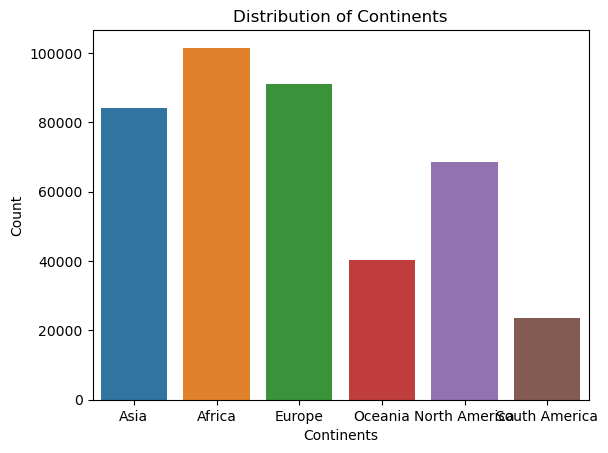

In [29]:
sns.countplot( data = df , x = 'continent' , hue = 'continent')
plt.title("Distribution of Continents")
plt.xlabel("Continents")
plt.ylabel("Count")
plt.show()

In [30]:
df

,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,total_vaccinations,people_vaccinated,people_fully_vaccinated,new_vaccinations,population_density,year
0,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.422,2020
1,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.422,2020
2,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.422,2020
3,Asia,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.422,2020
4,Asia,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,54.422,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,Africa,Zimbabwe,2024-07-31,266386.0,0.0,5740.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.729,2024
429431,Africa,Zimbabwe,2024-08-01,266386.0,0.0,5740.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.729,2024
429432,Africa,Zimbabwe,2024-08-02,266386.0,0.0,5740.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.729,2024
429433,Africa,Zimbabwe,2024-08-03,266386.0,0.0,5740.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42.729,2024


# Bivarient Analysis

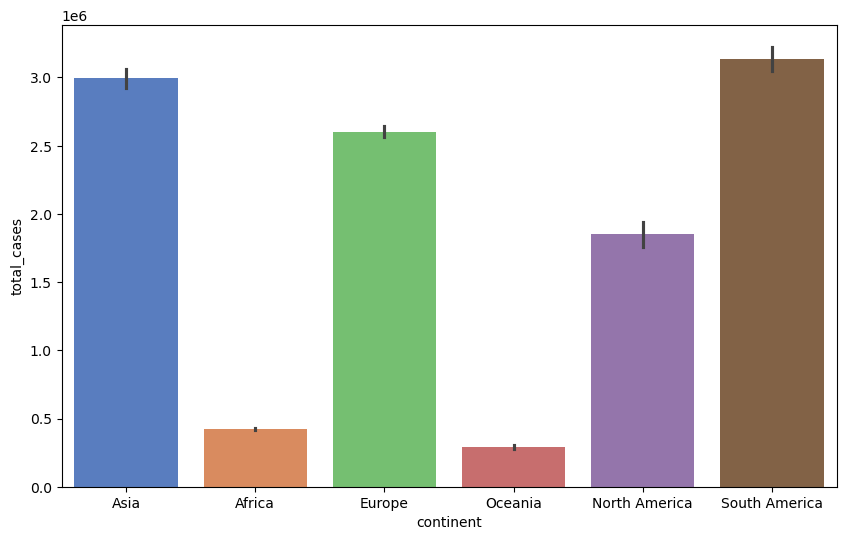

In [32]:
# continent wise totalcases
plt.figure(figsize=(10, 6))
sns.barplot(x='continent', y='total_cases', data=df, palette='muted')
plt.show()

## Africa has the maximum number of total_cases from the year 2020 to 2024 followed by South America

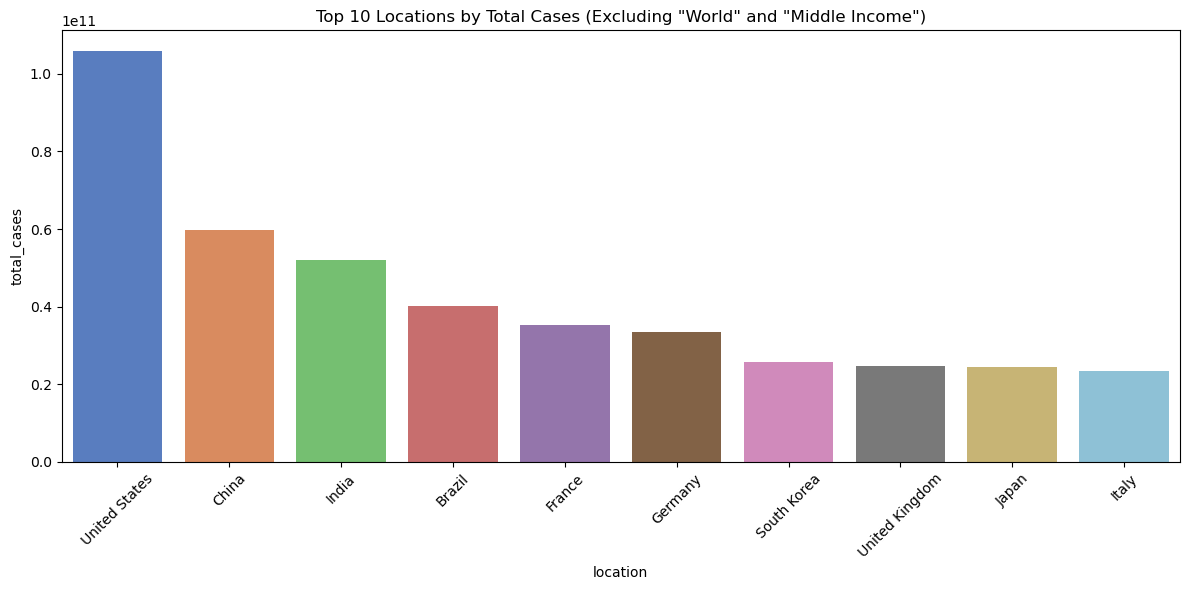

In [34]:
# Group by location and sum total_cases
grouped = df.groupby('location', as_index=False)['total_cases'].sum()

# Get top 10 locations by total_cases
top_10 = grouped.sort_values(by='total_cases', ascending=False).head(10)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='location', y='total_cases', data=top_10, palette='muted')
plt.xticks(rotation=45)
plt.title('Top 10 Locations by Total Cases (Excluding "World" and "Middle Income")')
plt.tight_layout()
plt.show()

## United States is the most affected country, with total cases significantly higher than any other location, indicating a major share of global infections. China, India, and Brazil follow in the next positions, also showing high case numbers, though they trail the U.S. by a substantial margin.

In [36]:
yearly_data = df.groupby('year')[['new_deaths','new_cases','new_vaccinations']].sum().reset_index()

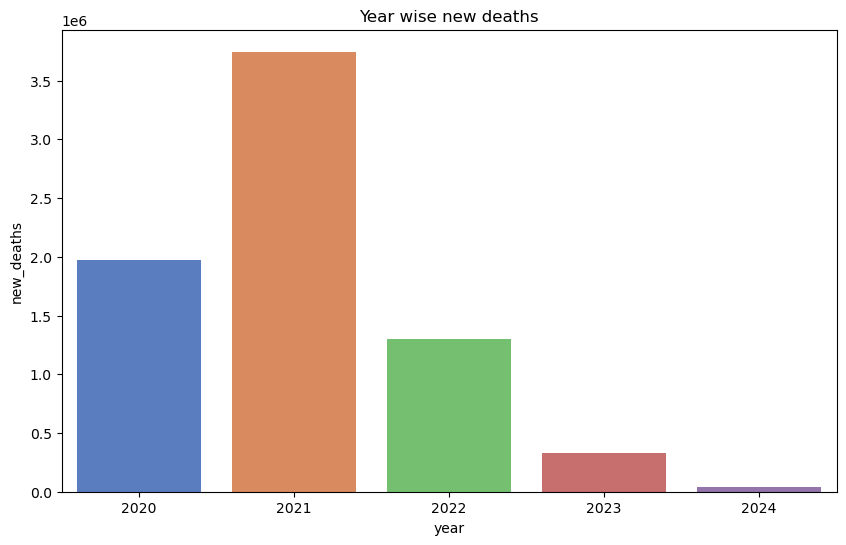

In [37]:
# year wise totalcases
plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='new_deaths', data=yearly_data, palette='muted')
plt.title('Year wise new deaths')
plt.show()

## 2021 had the highest number of new deaths, peaking significantly compared to all other years. This indicates that the second year of the pandemic was the most severe in terms of mortality.2020, the initial year, also saw a substantial number of new deaths, but less than 2021—likely due to the pandemic's emergence and rapid global spread.2022 onwards shows a sharp decline in new deaths, possibly reflecting:Increased vaccination coverage, Better medical preparedness and treatments, Virus mutation into less deadly variants (like Omicron), 2023 and 2024 have very low new death figures, highlighting how the pandemic was effectively controlled or became endemic with minimal fatality impact.

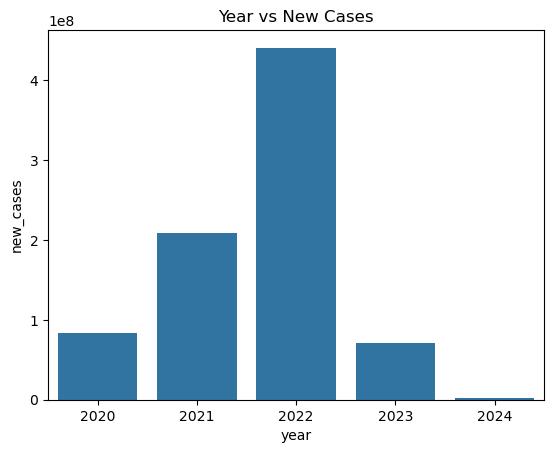

In [39]:
# Group by year and calculate sum
sns.barplot(x='year', y='new_cases', data=yearly_data)
plt.title('Year vs New Cases')
plt.show()

## There was a sharp increase in new cases from 2020 to 2023.
## The most significant jump occurred between 2021 and 2022, and again between 2022 and 2023, suggesting major waves or outbreaks in those years.
## A noticeable drop in 2024 suggests that the pandemic began to come under control or that testing/reporting decreased.
## Could be attributed to increased vaccinations, natural immunity, or changes in variants and policy.
## As expected, 2020 shows the lowest case count since it marked the beginning of the pandemic, with slower spread and limited testing in the early months.

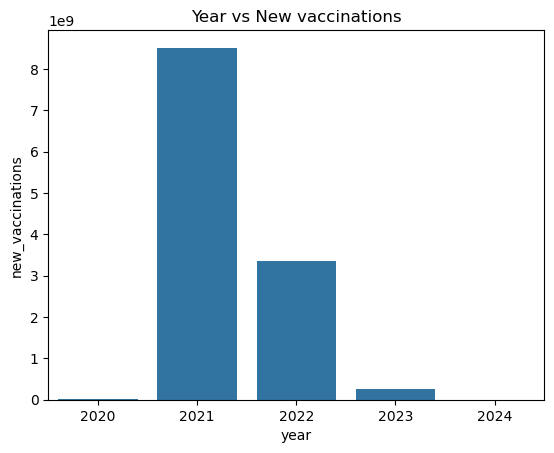

In [41]:
# Group by year and calculate sum
sns.barplot(x='year', y='new_vaccinations', data=yearly_data)
plt.title('Year vs New vaccinations')
plt.show()

## The year 2021 shows an enormous spike in vaccinations.This aligns with the global emergency vaccine approvals and initial mass immunization campaigns.
## 2022 saw a notable drop, but still a substantial number of new vaccinations—likely due to second doses, booster shots, and extended vaccine availability.2023 and 2024 show a steep decline, almost negligible compared to previous years, indicating:Most of the population may have already been vaccinated.Very few vaccinations were recorded in 2020, which makes sense as vaccines were still in development and not publicly available.

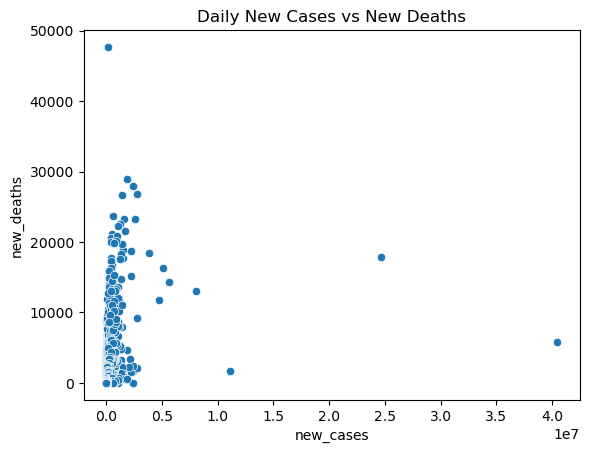

In [43]:
# Daily New Cases vs New Deaths
sns.scatterplot(x='new_cases', y='new_deaths', data=df)
plt.title('Daily New Cases vs New Deaths')
plt.show()

## Positive Correlation in Low-to-Mid Range:
## As new cases increase (especially between 0 to 40 million), new deaths also tend to rise, forming upward clusters. This suggests a direct impact of case surges on daily death counts during early or peak waves.
## High Cases, Lower Deaths (Right-End of X-axis): For very high new case values (≥60 million), new deaths appear comparatively low or flat, indicating: Improved medical treatments or less severe variants (e.g., Omicron), Mass vaccination impact reducing mortality even as infections surged, Better hospital readiness or public health interventions.


In [45]:
cat = []
num = []

for i in df.columns:
    if df[i].dtype == 'O':
        cat.append(i)
    else:
        num.append(i)

In [46]:
cat

['continent', 'location']

In [47]:
num

['date',
 'total_cases',
 'new_cases',
 'total_deaths',
 'new_deaths',
 'total_tests',
 'new_tests',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'new_vaccinations',
 'population_density',
 'year']

In [48]:
df_new=df.drop(['continent','location'], axis=1)

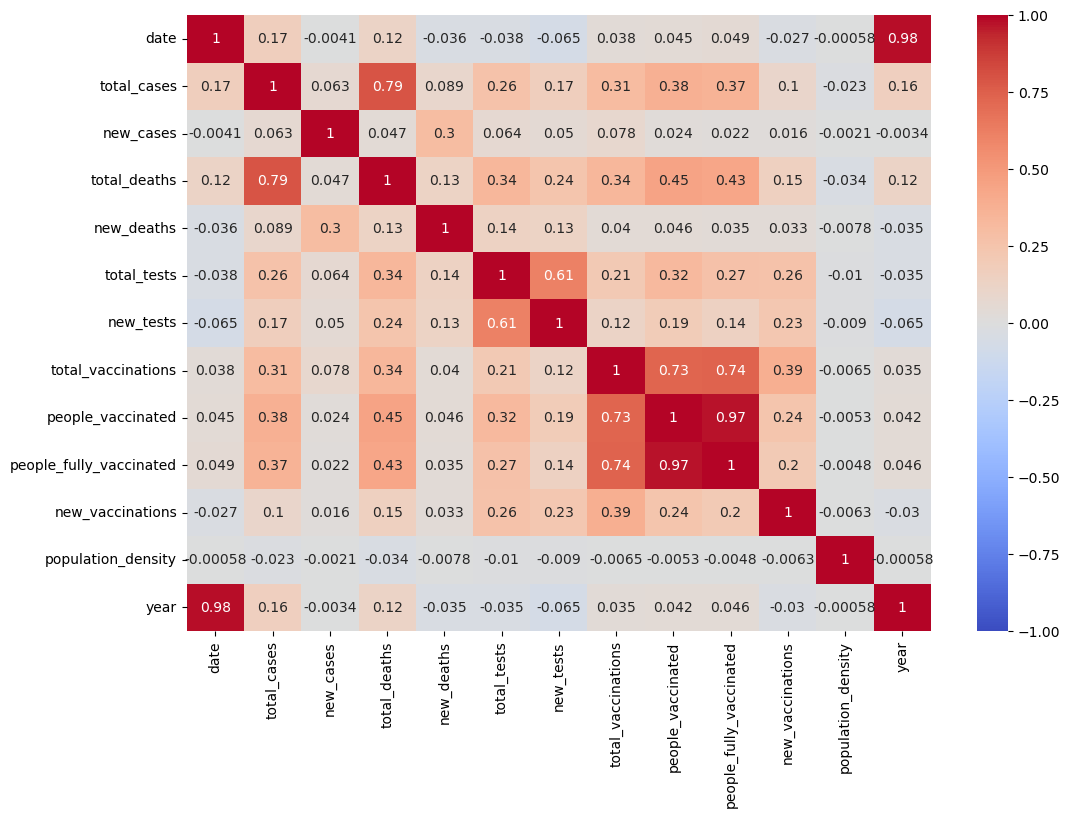

In [49]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_new.corr(), vmin= -1.0, annot=True, cmap='coolwarm')
plt.show()

## There is high correlation between people vaccinated and people fully vaccinated. Because people fully vaccinated means all the 3 doses of vaccinations are done. People vaccinated means only either of the one or two vaccinations are done.